# Prediction of PD - Level 4

In [29]:
!pip install -U pip
!pip install autogluon.tabular[all]

In [30]:
!pip install -q shap lime

In [31]:
import os
import json
import math
import warnings
from pathlib import Path
import shutil
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss

from autogluon.tabular import TabularPredictor

from sklearn.tree import plot_tree


import shap
from lime.lime_tabular import LimeTabularExplainer

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.calibration import calibration_curve


warnings.filterwarnings("ignore")

# 0) User Config

In [32]:
TRAIN_PATH = "/content/train_raw.csv"
VAL_PATH   = "/content/val_raw.csv"
TEST_PATH  = "/content/test_raw.csv"

OUT_DIR = "/content/autogluon_level4_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

EXPLAIN_DIR = os.path.join(OUT_DIR, "explainability")
os.makedirs(EXPLAIN_DIR, exist_ok=True)

PLOT_DIR = "/content/thesis_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

TARGET = "Default"

SEED = 42

TIME_LIMIT = 600  # for summery

CONSERVATISM_UPLIFT = 0.30

APPLY_PD_FLOOR = True
PD_FLOOR = 0.0005

MOC_A_UPLIFT = 0.05

# Bootstrap sizes, lower numbers as each time a new model is created --> high costs
N_BOOT_TEST = 5
N_BOOT_TRAIN = 3
BOOTSTRAP_TIME_LIMIT = 60

# Rating-grade logic
N_RISK_GRADES = 10
MIN_GRADE_SHARE = 0.03       # minimum 3% per grade, used as diagnostic

# Governance-constrained AutoML search space
# Only comparatively interpretable model families are allowed:
# LR = linear/logistic model
# RF = Random Forest
# XT = Extra Trees

CONSTRAINED_AUTOML_HYPERPARAMETERS = {
    "LR": {},
    "RF": {},
    "XT": {},
}


# 1) Load fixed splits

In [33]:
train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)

Train shape: (153207, 17)
Val shape: (51070, 17)
Test shape: (51070, 17)


In [34]:
train = train.dropna(subset=[TARGET]).copy()
val = val.dropna(subset=[TARGET]).copy()
test = test.dropna(subset=[TARGET]).copy()

train[TARGET] = train[TARGET].astype(int)
val[TARGET] = val[TARGET].astype(int)
test[TARGET] = test[TARGET].astype(int)

# 2) Helper functions

In [35]:
def logit(p):
    p = np.clip(np.asarray(p, dtype=float), 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p))


def inv_logit(z):
    return 1 / (1 + np.exp(-np.asarray(z, dtype=float)))


def ks_statistic(y_true, pd_pred):
    tmp = pd.DataFrame({
        "y": np.asarray(y_true).astype(int),
        "pd": np.asarray(pd_pred)
    }).sort_values("pd", ascending=False)

    total_bad = max((tmp["y"] == 1).sum(), 1)
    total_good = max((tmp["y"] == 0).sum(), 1)

    cum_bad = (tmp["y"] == 1).cumsum() / total_bad
    cum_good = (tmp["y"] == 0).cumsum() / total_good

    return float(np.max(np.abs(cum_bad - cum_good)))


def calibration_table(y_true, pd_pred, n_buckets=10):
    tmp = pd.DataFrame({
        "y": np.asarray(y_true).astype(int),
        "pd": np.asarray(pd_pred)
    })

    tmp["bucket"] = pd.qcut(tmp["pd"], q=n_buckets, duplicates="drop")

    out = tmp.groupby("bucket", observed=False).agg(
        obs=("y", "count"),
        defaults=("y", "sum"),
        avg_pd=("pd", "mean"),
        pd_min=("pd", "min"),
        pd_max=("pd", "max"),
    ).reset_index()

    out["observed_dr"] = out["defaults"] / out["obs"]
    out["calibration_gap"] = out["avg_pd"] - out["observed_dr"]

    return out


def hosmer_lemeshow_like(y_true, pd_pred, n_buckets=10):
    tab = calibration_table(y_true, pd_pred, n_buckets)
    eps = 1e-8

    expected_bad = np.clip(tab["avg_pd"] * tab["obs"], eps, None)
    expected_good = np.clip((1 - tab["avg_pd"]) * tab["obs"], eps, None)

    observed_bad = tab["defaults"]
    observed_good = tab["obs"] - tab["defaults"]

    hl = ((observed_bad - expected_bad) ** 2 / expected_bad).sum()
    hl += ((observed_good - expected_good) ** 2 / expected_good).sum()

    return float(hl)


def evaluate_pd(y_true, pd_pred, prefix):
    auc = roc_auc_score(y_true, pd_pred)

    return {
        f"{prefix}_auc": float(auc),
        f"{prefix}_gini": float(2 * auc - 1),
        f"{prefix}_ks": ks_statistic(y_true, pd_pred),
        f"{prefix}_brier": float(brier_score_loss(y_true, pd_pred)),
        f"{prefix}_logloss": float(log_loss(y_true, pd_pred)),
        f"{prefix}_hl_like": hosmer_lemeshow_like(y_true, pd_pred),
        f"{prefix}_mean_pd": float(np.mean(pd_pred)),
        f"{prefix}_obs_dr": float(np.mean(y_true)),
    }


def population_stability_index(reference, current, buckets=10):
    reference = pd.Series(reference).astype(float)
    current = pd.Series(current).astype(float)

    cuts = np.unique(np.quantile(reference, np.linspace(0, 1, buckets + 1)))

    if len(cuts) < 3:
        return 0.0

    cuts[0] = -np.inf
    cuts[-1] = np.inf

    reference_bins = pd.cut(reference, bins=cuts, include_lowest=True)
    current_bins = pd.cut(current, bins=cuts, include_lowest=True)

    reference_dist = reference_bins.value_counts(normalize=True, sort=False)
    current_dist = current_bins.value_counts(normalize=True, sort=False)

    psi = 0.0
    for bucket in reference_dist.index:
        pe = max(float(reference_dist.get(bucket, 0)), 1e-8)
        pa = max(float(current_dist.get(bucket, 0)), 1e-8)
        psi += (pa - pe) * math.log(pa / pe)

    return float(psi)


def calibrate_to_target_lradr(pd_values, target_mean, tol=1e-12):
    """
    Apply one global logit shift so that the average PD equals the proxy LRADR.
    """
    if not (0 < target_mean < 1):
        raise ValueError("target_mean must be between 0 and 1")

    base_logit = logit(pd_values)

    lower = -20.0
    upper = 20.0

    for _ in range(250):
        alpha = (lower + upper) / 2
        calibrated_pd = inv_logit(base_logit + alpha)

        if abs(calibrated_pd.mean() - target_mean) < tol:
            break

        if calibrated_pd.mean() < target_mean:
            lower = alpha
        else:
            upper = alpha

    return inv_logit(base_logit + alpha), float(alpha)


def apply_final_pd_adjustments(pd_be, moc_a=None, moc_c=None, pd_floor=PD_FLOOR):
    pd_final = np.asarray(pd_be, dtype=float)

    if moc_a is not None:
        pd_final = pd_final + np.asarray(moc_a, dtype=float)

    if moc_c is not None:
        pd_final = pd_final + np.asarray(moc_c, dtype=float)

    if APPLY_PD_FLOOR:
        pd_final = np.maximum(pd_final, pd_floor)

    return np.clip(pd_final, 0, 1)

def initial_pd_quantile_grades(df, pd_col, n_grades=N_RISK_GRADES):
    out = df.copy()
    out["risk_grade"] = pd.qcut(
        out[pd_col],
        q=n_grades,
        labels=False,
        duplicates="drop"
    ) + 1

    return out


def risk_grade_table(df, target_col, pd_cols, grade_col="risk_grade"):
    agg_dict = {
        "obs": (target_col, "count"),
        "defaults": (target_col, "sum"),
    }

    for col in pd_cols:
        agg_dict[f"avg_{col}"] = (col, "mean")
        agg_dict[f"min_{col}"] = (col, "min")
        agg_dict[f"max_{col}"] = (col, "max")

    tab = df.groupby(grade_col, observed=False).agg(**agg_dict).reset_index()
    tab["observed_dr"] = tab["defaults"] / tab["obs"]

    if f"avg_{pd_cols[-1]}" in tab.columns:
        tab["gap_final"] = tab[f"avg_{pd_cols[-1]}"] - tab["observed_dr"]

    tab["obs_share"] = tab["obs"] / tab["obs"].sum()
    tab["observed_dr_monotonic_increasing"] = tab["observed_dr"].is_monotonic_increasing

    return tab


def enforce_monotonic_grade_table(tab, grade_col="risk_grade"):
    """
    Conservative post-processing:
    If neighboring grades violate monotonic observed default rates,
    merge them until observed DR is monotonic increasing.

    This produces a rating table. It does not change the model PDs.
    """
    work = tab.copy()
    work["grade_group"] = work[grade_col].astype(str)

    while True:
        dr = work["observed_dr"].values
        violations = np.where(np.diff(dr) < 0)[0]

        if len(violations) == 0:
            break

        i = int(violations[0])

        # merge row i and i+1
        merged = work.iloc[i].copy()
        nxt = work.iloc[i + 1].copy()

        merged["grade_group"] = f"{merged['grade_group']}-{nxt['grade_group']}"
        merged["obs"] = merged["obs"] + nxt["obs"]
        merged["defaults"] = merged["defaults"] + nxt["defaults"]

        for col in work.columns:
            if col.startswith("avg_"):
                base = col.replace("avg_", "")
                # weighted average of averages
                merged[col] = (
                    work.iloc[i][col] * work.iloc[i]["obs"] +
                    work.iloc[i + 1][col] * work.iloc[i + 1]["obs"]
                ) / merged["obs"]

            if col.startswith("min_"):
                merged[col] = min(work.iloc[i][col], work.iloc[i + 1][col])

            if col.startswith("max_"):
                merged[col] = max(work.iloc[i][col], work.iloc[i + 1][col])

        merged["observed_dr"] = merged["defaults"] / merged["obs"]
        merged["obs_share"] = np.nan
        if "gap_final" in work.columns:
            final_avg_cols = [c for c in work.columns if c.startswith("avg_PD_final")]
            if final_avg_cols:
                merged["gap_final"] = merged[final_avg_cols[0]] - merged["observed_dr"]

        work = pd.concat(
            [work.iloc[:i], pd.DataFrame([merged]), work.iloc[i + 2:]],
            ignore_index=True
        )

    work["final_risk_grade"] = np.arange(1, len(work) + 1)
    work["obs_share"] = work["obs"] / work["obs"].sum()
    work["observed_dr_monotonic_increasing"] = work["observed_dr"].is_monotonic_increasing

    return work


def assign_final_grades_from_mapping(df, mapping_table, initial_grade_col="risk_grade"):
    """
    Assign merged final grades back to observations.
    """
    out = df.copy()

    lookup = []
    for _, row in mapping_table.iterrows():
        group = str(row["grade_group"])
        parts = [int(x) for x in group.split("-")]
        low = min(parts)
        high = max(parts)

        for g in range(low, high + 1):
            lookup.append({
                initial_grade_col: g,
                "final_risk_grade": int(row["final_risk_grade"])
            })

    lookup = pd.DataFrame(lookup)
    out = out.merge(lookup, on=initial_grade_col, how="left")

    return out

# Probability-space calibration via logit shift
def bootstrap_moc_c_autogluon(
    train_data,
    eval_data,
    calibration_alpha,
    n_boot=5,
    alpha_q=0.95,
    random_state=42,
):
    rng = np.random.RandomState(random_state)
    all_pd_predictions = []

    train_data = train_data.reset_index(drop=True)
    eval_data = eval_data.reset_index(drop=True)

    for b in range(n_boot):
        sample_idx = rng.randint(0, len(train_data), len(train_data))
        train_boot = train_data.iloc[sample_idx].reset_index(drop=True)

        boot_model_path = os.path.join(OUT_DIR, f"ag_level4_bootstrap_model_{b}")

        predictor_boot = TabularPredictor(
            label=TARGET,
            problem_type="binary",
            eval_metric="average_precision",
            sample_weight='balance_weight',
            path=boot_model_path,
        )

        predictor_boot.fit(
            train_data=train_boot,
            time_limit=BOOTSTRAP_TIME_LIMIT,
            hyperparameters=CONSTRAINED_AUTOML_HYPERPARAMETERS,
            num_bag_folds=0,
            num_stack_levels=0,
            use_bag_holdout=False,
            verbosity=0,
        )

        pd_raw = get_positive_class_proba(predictor_boot, eval_data)
        pd_calibrated = inv_logit(logit(pd_raw) + calibration_alpha)

        all_pd_predictions.append(pd_calibrated)

        if os.path.exists(boot_model_path):
            shutil.rmtree(boot_model_path, ignore_errors=True)

    pred_matrix = np.vstack(all_pd_predictions)

    pd_mean = pred_matrix.mean(axis=0)
    pd_quantile = np.quantile(pred_matrix, alpha_q, axis=0)

    moc_c = np.maximum(pd_quantile - pd_mean, 0.0)

    return pd_mean, moc_c, pred_matrix

def get_positive_class_proba(predictor, data, positive_class=1, model=None):
    proba = predictor.predict_proba(data, model=model)

    if isinstance(proba, pd.DataFrame):
        if positive_class in proba.columns:
            return proba[positive_class].values
        if str(positive_class) in proba.columns:
            return proba[str(positive_class)].values
        return proba.iloc[:, -1].values

    return np.asarray(proba)[:, -1]

#### Helper functions for the model in the restricted search space

def get_best_autogluon_model_object(predictor, best_model):
    """
    Loads the internal fitted AutoGluon model object.
    """
    return predictor._trainer.load_model(best_model)

def save_tree_visualization_if_available(
    predictor,
    best_model,
    feature_names,
    output_dir,
    max_depth=3,
):
    """
    Saves a visualization of one representative tree if the selected model
    is Random Forest or Extra Trees.
    """

    model_obj = get_best_autogluon_model_object(predictor, best_model)

    if not hasattr(model_obj, "model"):
        print("No internal sklearn-like model available.")
        return

    sklearn_model = model_obj.model

    if not hasattr(sklearn_model, "estimators_"):
        print(f"Best model {best_model} is not a tree ensemble with estimators_.")
        return

    tree = sklearn_model.estimators_[0]

    plt.figure(figsize=(28, 14))

    plot_tree(
        tree,
        feature_names=list(feature_names),
        filled=True,
        rounded=True,
        max_depth=max_depth,
        fontsize=8,
    )

    tree_path = os.path.join(output_dir, f"{best_model}_representative_tree.png")
    plt.savefig(tree_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved representative tree plot to: {tree_path}")

def save_linear_coefficients_if_available(
    predictor,
    best_model,
    feature_names,
    output_dir,
):
    """
    Saves coefficients if the selected AutoGluon model is linear/logistic.
    Handles transformed feature names if available.
    """

    model_obj = get_best_autogluon_model_object(predictor, best_model)

    if not hasattr(model_obj, "model"):
        print("No internal model object available.")
        return

    sklearn_model = model_obj.model

    if not hasattr(sklearn_model, "coef_"):
        print(f"Best model {best_model} has no coefficients.")
        return

    coef = sklearn_model.coef_.ravel()

    if hasattr(sklearn_model, "feature_names_in_"):
        coef_features = list(sklearn_model.feature_names_in_)
    elif len(feature_names) == len(coef):
        coef_features = list(feature_names)
    else:
        coef_features = [f"transformed_feature_{i}" for i in range(len(coef))]
        print(
            f"Feature name mismatch: {len(feature_names)} original features "
            f"but {len(coef)} coefficients. Using generic transformed feature names."
        )

    coef_df = pd.DataFrame({
        "feature": coef_features,
        "coefficient": coef,
    }).sort_values("coefficient", ascending=False)

    coef_df.to_csv(
        os.path.join(output_dir, f"{best_model}_coefficients.csv"),
        index=False
    )

    plt.figure(figsize=(10, 8))
    coef_df.sort_values("coefficient").plot(
        x="feature",
        y="coefficient",
        kind="barh",
        legend=False
    )

    plt.title(f"Linear Model Coefficients: {best_model}")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")

    coef_plot_path = os.path.join(output_dir, f"{best_model}_coefficients.png")
    plt.savefig(coef_plot_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved coefficient plot to: {coef_plot_path}")


# if ensamble --> best basis model
def get_best_non_ensemble_model_from_leaderboard(predictor, data):
    """
    Returns the best non-ensemble model from the AutoGluon leaderboard.
    This is useful when the overall best model is a WeightedEnsemble.
    """
    lb = predictor.leaderboard(data, silent=True)

    non_ensemble_lb = lb[
        ~lb["model"].str.contains("WeightedEnsemble", case=False, na=False)
    ].copy()

    if non_ensemble_lb.empty:
        raise ValueError("No non-ensemble base model found in leaderboard.")

    return non_ensemble_lb.iloc[0]["model"]


# 3) AutoGluon initial training and tuning

In [36]:
predictor = TabularPredictor(
    label=TARGET,
    problem_type="binary",
    eval_metric="average_precision",
    sample_weight='balance_weight',
   path=f"{OUT_DIR}/ag_model_level4"
)

predictor.fit(
    train_data=train,
    tuning_data=val,
    hyperparameters=CONSTRAINED_AUTOML_HYPERPARAMETERS,
    num_bag_folds=0,
    num_stack_levels=0,
    time_limit=600
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.46 GB / 12.67 GB (82.6%)
Disk Space Avail:   73.11 GB / 107.72 GB (67.9%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, TabDPT, and TabM. Requires a GPU and `pip install au

 ## 3.1) AutoGluon Final refit on train + validation

In [37]:
# refit_full() --> The selected models are retrained on the complete development dataset, consisting of both the training and validation partitions

predictor.refit_full()

best_model_final = predictor.model_best

print("Best final model:", best_model_final)

Refitting models via `predictor.refit_full` using all of the data (combined train and validation)...
	Models trained in this way will have the suffix "_FULL" and have NaN validation score.
	This process is not bound by time_limit, but should take less time than the original `predictor.fit` call.
	To learn more, refer to the `.refit_full` method docstring which explains how "_FULL" models differ from normal models.
Fitting 1 L1 models, fit_strategy="sequential" ...
Fitting model: RandomForest_FULL ...
	Fitting with cpus=2, gpus=0, mem=1.0/9.1 GB
	182.87s	 = Training   runtime
Fitting 1 L1 models, fit_strategy="sequential" ...
Fitting model: ExtraTrees_FULL ...
	Fitting with cpus=2, gpus=0, mem=1.0/9.0 GB
	67.71s	 = Training   runtime
Fitting 1 L1 models, fit_strategy="sequential" ...
Fitting model: LinearModel_FULL ...
	Fitting with cpus=2, gpus=0, mem=0.1/10.1 GB
	3.1s	 = Training   runtime
Fitting model: WeightedEnsemble_L2_FULL | Skipping fit via cloning parent ...
	Ensemble Weights:

Best final model: WeightedEnsemble_L2_FULL


# 4) Evaluation on unseen data

In [38]:
test_results = predictor.evaluate(
    test,
    model=best_model_final
)

print(test_results)

{'average_precision': np.float64(0.32384670190466325), 'accuracy': 0.8436851380458195, 'balanced_accuracy': np.float64(0.641808851819182), 'mcc': np.float64(0.2718242369876419), 'roc_auc': np.float64(0.758208640001891), 'f1': 0.3601827362346718, 'precision': 0.34326306141154905, 'recall': 0.37885685381891754}


# 5) Leaderboard

In [39]:
leaderboard = predictor.leaderboard(
    test,
    extra_metrics=[
        "accuracy",
        "balanced_accuracy",
        "f1",
        "log_loss"
    ],
    silent=True
)

print(leaderboard)

leaderboard.to_csv(
    os.path.join(OUT_DIR, "leaderboard_test.csv"),
    index=False
)

                      model  score_test  accuracy  balanced_accuracy  \
0  WeightedEnsemble_L2_FULL    0.323847  0.843685           0.641809   
1       WeightedEnsemble_L2    0.322075  0.862640           0.611305   
2           ExtraTrees_FULL    0.320135  0.867828           0.604868   
3                ExtraTrees    0.318045  0.881437           0.570534   
4         RandomForest_FULL    0.316147  0.884218           0.555119   
5          LinearModel_FULL    0.310537  0.676444           0.686257   
6               LinearModel    0.310200  0.676562           0.687129   
7              RandomForest    0.308454  0.885353           0.514169   

         f1  log_loss  score_val        eval_metric  pred_time_test  \
0  0.360183 -0.423875        NaN  average_precision        7.251878   
1  0.324376 -0.398362   0.312812  average_precision       11.921515   
2  0.315555 -0.385820        NaN  average_precision        3.241122   
3  0.244918 -0.352901   0.309883  average_precision        5.276196

# 6) Best AutoGluon model

In [40]:
best_test_model = leaderboard.iloc[0]["model"]

print(
    "Best model on test leaderboard, only reported, not selected:",
    best_test_model
)

Best model on test leaderboard, only reported, not selected: WeightedEnsemble_L2_FULL


## 6.1) Retricted Search space specific

In [41]:
FEATURES = [c for c in train.columns if c != TARGET]

save_tree_visualization_if_available(
    predictor=predictor,
    best_model=best_model_final,
    feature_names=FEATURES,
    output_dir=EXPLAIN_DIR,
)

save_linear_coefficients_if_available(
    predictor=predictor,
    best_model=best_model_final,
    feature_names=FEATURES,
    output_dir=EXPLAIN_DIR,
)

Best model WeightedEnsemble_L2_FULL is not a tree ensemble with estimators_.
Best model WeightedEnsemble_L2_FULL has no coefficients.


## 6.2) Base model

In [42]:
best_base_model = get_best_non_ensemble_model_from_leaderboard(
    predictor=predictor,
    data=val,
)

print("Best AutoGluon model:", best_model_final)
print("Best non-ensemble base model:", best_base_model)

Best AutoGluon model: WeightedEnsemble_L2_FULL
Best non-ensemble base model: RandomForest_FULL


In [43]:
save_tree_visualization_if_available(
    predictor=predictor,
    best_model=best_base_model,
    feature_names=FEATURES,
    output_dir=EXPLAIN_DIR,
)

save_linear_coefficients_if_available(
    predictor=predictor,
    best_model=best_base_model,
    feature_names=FEATURES,
    output_dir=EXPLAIN_DIR,
)

Saved representative tree plot to: /content/autogluon_level4_outputs/explainability/RandomForest_FULL_representative_tree.png
Best model RandomForest_FULL has no coefficients.


#7) Calibration

In [44]:
train_final = pd.concat([train, val], axis=0).reset_index(drop=True)
test_final = test.copy().reset_index(drop=True)

y_train_final = train_final[TARGET].astype(int).values
y_test_final = test_final[TARGET].astype(int).values

# Raw AutoGluon PDs
pd_train_raw = get_positive_class_proba(
    predictor,
    train_final,
    model=best_model_final
)

pd_test_raw = get_positive_class_proba(
    predictor,
    test_final,
    model=best_model_final
)

# BE-PD is with shift
# Best-estimate calibration to proxy LRADR
observed_train_dr = float(np.mean(y_train_final))

proxy_lradr = observed_train_dr * (1 + CONSERVATISM_UPLIFT)
proxy_lradr = min(max(proxy_lradr, 1e-6), 1 - 1e-6)

pd_train_be, alpha_shift = calibrate_to_target_lradr(
    pd_train_raw,
    proxy_lradr
)

pd_test_be = inv_logit(logit(pd_test_raw) + alpha_shift)

# MoC_C via bootstrap
pd_train_boot_mean, moc_c_train, pred_matrix_train = bootstrap_moc_c_autogluon(
    train_data=train_final,
    eval_data=train_final,
    calibration_alpha=alpha_shift,
    n_boot=N_BOOT_TRAIN,
    alpha_q=0.95,
    random_state=SEED,
)

pd_test_boot_mean, moc_c_test, pred_matrix_test = bootstrap_moc_c_autogluon(
    train_data=train_final,
    eval_data=test_final,
    calibration_alpha=alpha_shift,
    n_boot=N_BOOT_TEST,
    alpha_q=0.95,
    random_state=SEED + 1,
)

# MoC_A
moc_a_train = pd_train_be * MOC_A_UPLIFT
moc_a_test = pd_test_be * MOC_A_UPLIFT

# Final PDs
pd_train_final = apply_final_pd_adjustments(
    pd_be=pd_train_be,
    moc_a=moc_a_train,
    moc_c=moc_c_train,
)

pd_test_final = apply_final_pd_adjustments(
    pd_be=pd_test_be,
    moc_a=moc_a_test,
    moc_c=moc_c_test,
)

print("Observed train DR:", observed_train_dr)
print("Proxy LRADR:", proxy_lradr)
print("Alpha shift:", alpha_shift)
print("Mean MoC_A test:", np.mean(moc_a_test))
print("Mean MoC_C test:", np.mean(moc_c_test))
print("Mean final PD test:", np.mean(pd_test_final))

# for documentation
pd_train_final_pre_floor = np.clip(pd_train_be + moc_a_train + moc_c_train, 0, 1)
pd_test_final_pre_floor = np.clip(pd_test_be + moc_a_test + moc_c_test, 0, 1)

# metrics
raw_train_metrics = evaluate_pd(y_train_final, pd_train_raw, "train_raw")
raw_test_metrics = evaluate_pd(y_test_final, pd_test_raw, "test_raw")
be_train_metrics = evaluate_pd(y_train_final, pd_train_be, "train_be")
be_test_metrics = evaluate_pd(y_test_final, pd_test_be, "test_be")
final_train_metrics = evaluate_pd(y_train_final, pd_train_final, "train_final")
final_test_metrics = evaluate_pd(y_test_final, pd_test_final, "test_final")

# Observation-level result table
pd_results_test = test_final.drop(columns=[TARGET]).copy()
pd_results_test["Default_Observed"] = np.asarray(y_test_final)
pd_results_test["PD_raw"] = pd_test_raw
pd_results_test["PD_BE"] = pd_test_be
pd_results_test["MoC_A"] = moc_a_test
pd_results_test["MoC_C"] = moc_c_test

# pds befor
pd_results_test["PD_BE_plus_MoC"] = (
    pd_results_test["PD_BE"]
    + pd_results_test["MoC_A"]
    + pd_results_test["MoC_C"]
)

pd_results_test["PD_final_pre_floor"] = pd_test_final_pre_floor
pd_results_test["PD_final"] = pd_test_final

# Scorecard-like monotonic rating mapping
pd_results_test = initial_pd_quantile_grades(
    df=pd_results_test,
    pd_col="PD_final",
    n_grades=N_RISK_GRADES
)

initial_grade_table = risk_grade_table(
    df=pd_results_test,
    target_col="Default_Observed",
    pd_cols=["PD_raw", "PD_BE", "PD_final"],
    grade_col="risk_grade"
)

scorecard_df = enforce_monotonic_grade_table(initial_grade_table)

pd_results_test = assign_final_grades_from_mapping(
    df=pd_results_test,
    mapping_table=scorecard_df,
    initial_grade_col="risk_grade"
)

# final rank ordering table after merged monotonic grades
rank_ordering = risk_grade_table(
    df=pd_results_test,
    target_col="Default_Observed",
    pd_cols=["PD_raw", "PD_BE", "PD_final"],
    grade_col="final_risk_grade"
)


# Calibration tables
cal_table_raw = calibration_table(y_test_final, pd_test_raw, n_buckets=10)
cal_table_be = calibration_table(y_test_final, pd_test_be, n_buckets=10)
cal_table_final = calibration_table(y_test_final, pd_test_final, n_buckets=10)


# Stability summary
stability_summary = pd.DataFrame({
    "comparison": ["train_final_vs_test_final_raw_pd"],
    "psi": [population_stability_index(pd.Series(pd_train_raw), pd.Series(pd_test_raw))]
})

Observed train DR: 0.11612663197521013
Proxy LRADR: 0.15096462156777318
Alpha shift: -1.0361794830714643
Mean MoC_A test: 0.007321495419951615
Mean MoC_C test: 0.01617816351268382
Mean final PD test: 0.16992956733166772


# 8) Prepare data

In [45]:
X_train = train_final.drop(columns=[TARGET]).copy()
y_train = train_final[TARGET].astype(int)

X_test = test_final.drop(columns=[TARGET]).copy()
y_test = test_final[TARGET].astype(int)

# 9)  SHAP KernelExplainer

In [46]:
# explain final calibrated PD-Pipeline

X_background = X_train.sample(
    n=min(20, len(X_train)),
    random_state=42
)

X_shap = X_test.sample(
    n=min(30, len(X_test)),
    random_state=42
)


def predict_proba_fn(data):

    df = pd.DataFrame(
        data,
        columns=X_train.columns
    )

    pd_raw = get_positive_class_proba(
        predictor,
        df,
        model=best_model_final
    )

    pd_be = inv_logit(
        logit(pd_raw) + alpha_shift
    )

    moc_a = pd_be * MOC_A_UPLIFT

    moc_c = np.full_like(
        pd_be,
        np.mean(moc_c_test),
        dtype=float
    )

    pd_final = apply_final_pd_adjustments(
        pd_be=pd_be,
        moc_a=moc_a,
        moc_c=moc_c,
    )

    return pd_final


explainer = shap.KernelExplainer(
    predict_proba_fn,
    X_background
)

shap_values = explainer.shap_values(
    X_shap,
    nsamples=30
)


  0%|          | 0/30 [00:00<?, ?it/s]

## 9.1) SHAP Summery Plot

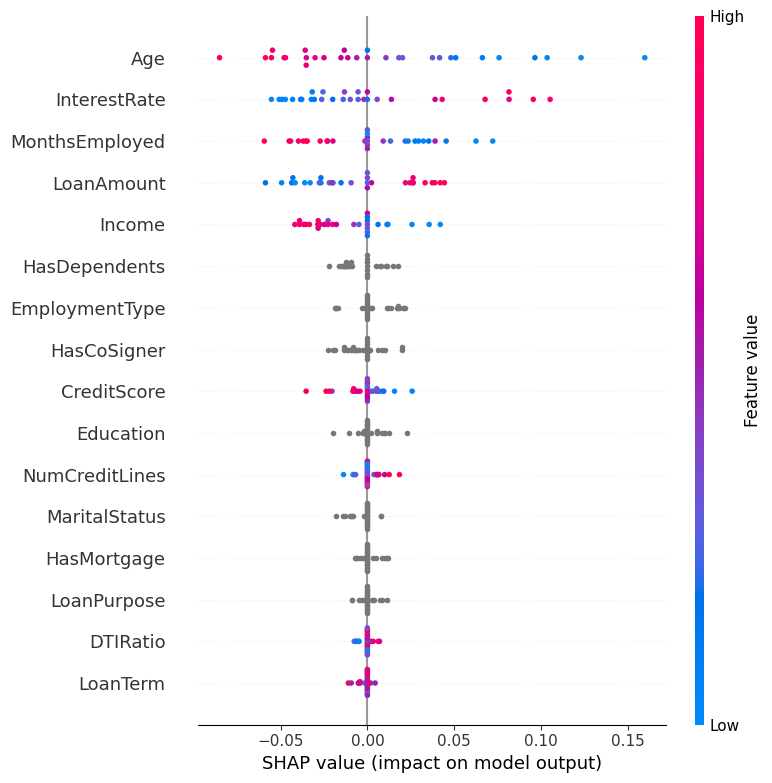

In [47]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    show=True
)

plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "shap_summary_plot.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

## 9.2) SHAP Bar Plot

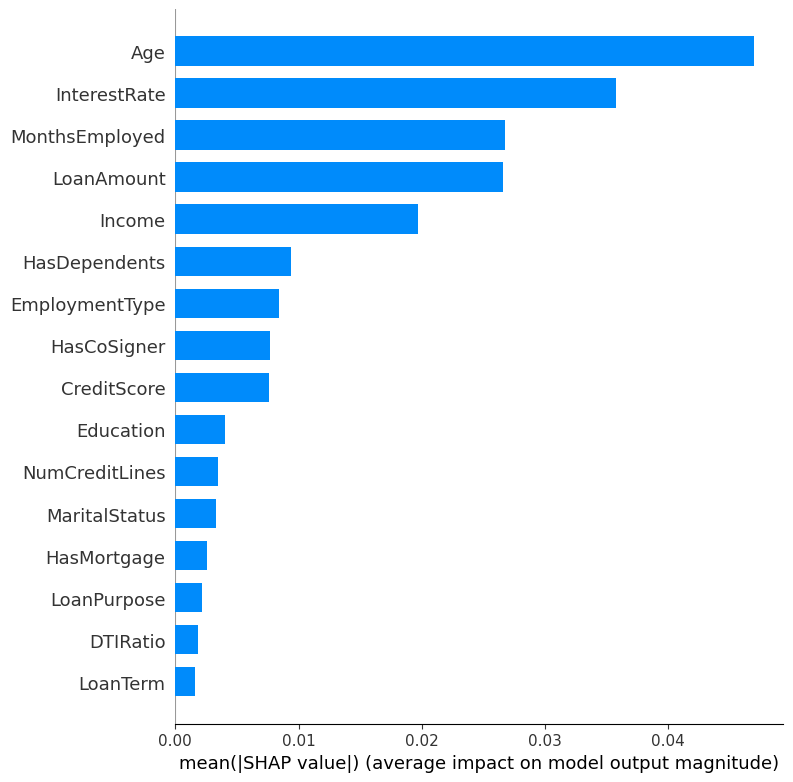

In [48]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=True
)

plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "shap_summary_bar_plot.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

# 10) LIME

In [49]:
X_train_lime = pd.get_dummies(X_train, drop_first=False)
X_test_lime = pd.get_dummies(X_test, drop_first=False)

X_test_lime = X_test_lime.reindex(
    columns=X_train_lime.columns,
    fill_value=0
)

X_train_lime = X_train_lime.astype(float)
X_test_lime = X_test_lime.astype(float)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=X_train_lime.columns.tolist(),
    class_names=["Non-Default", "Default"],
    mode="classification"
)

def predict_final_pd_from_encoded(data):

    df_encoded = pd.DataFrame(
        data,
        columns=X_train_lime.columns
    )

    df_original = pd.DataFrame(index=df_encoded.index)

    for col in X_train.columns:

        dummy_cols = [
            c for c in df_encoded.columns
            if c.startswith(f"{col}_")
        ]

        if dummy_cols:

            df_original[col] = (
                df_encoded[dummy_cols]
                .idxmax(axis=1)
                .str[len(col) + 1:]
            )

        else:
            df_original[col] = df_encoded[col]

    pd_raw = get_positive_class_proba(
        predictor,
        df_original,
        model=best_model_final
    )

    pd_be = inv_logit(logit(pd_raw) + alpha_shift)

    moc_a = pd_be * MOC_A_UPLIFT

    moc_c = np.full_like(
        pd_be,
        np.mean(moc_c_test)
    )

    return apply_final_pd_adjustments(
        pd_be=pd_be,
        moc_a=moc_a,
        moc_c=moc_c,
    )

def predict_proba_fn_lime(data):
    pd_final =  predict_final_pd_from_encoded(data)

    return np.column_stack([
        1 - pd_final,
        pd_final
    ])

instance_idx = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_lime.iloc[instance_idx].values,
    predict_fn=predict_proba_fn_lime,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

## 10.1) Save LIME explanation

In [50]:
lime_exp.save_to_file(
    os.path.join(OUT_DIR, "lime_explanation.html")
)

print("Level 4 explainability outputs saved.")

Level 4 explainability outputs saved.


# 11) Global permutation feature importance

In [51]:
# Feature importance computed by shuffling one feature at a time and measuring the resulting performance drop
# Higher values indicate stronger contribution to predictive performance.
# Negative values can indicate that a feature is harmful or unstable.

feature_importance = predictor.feature_importance(
    data=test,
    model=best_model_final,
    feature_stage="original",
    subsample_size=min(5000, len(test)),
    num_shuffle_sets=10,
    include_confidence_band=True,
    confidence_level=0.99,
    silent=True
)

print(feature_importance)

feature_importance.to_csv(
    os.path.join(EXPLAIN_DIR, "feature_importance_test_best_model.csv"),
    index=True
)

                importance    stddev       p_value   n  p99_high   p99_low
Age               0.104206  0.015074  2.068348e-09  10  0.119697  0.088715
Income            0.066734  0.009193  1.341890e-09  10  0.076182  0.057287
InterestRate      0.063592  0.011061  1.051371e-08  10  0.074959  0.052224
LoanAmount        0.042136  0.007038  7.360750e-09  10  0.049369  0.034903
MonthsEmployed    0.034724  0.007012  3.879664e-08  10  0.041930  0.027518
EmploymentType    0.009395  0.005700  2.774504e-04  10  0.015253  0.003537
HasCoSigner       0.008197  0.002817  3.555454e-06  10  0.011092  0.005302
HasDependents     0.004731  0.002284  5.254190e-05  10  0.007078  0.002384
CreditScore       0.004086  0.002267  1.473124e-04  10  0.006416  0.001756
LoanPurpose       0.003344  0.001677  7.006491e-05  10  0.005067  0.001620
Education         0.002977  0.003234  8.642806e-03  10  0.006301 -0.000347
NumCreditLines    0.002246  0.002647  1.253514e-02  10  0.004966 -0.000474
MaritalStatus     0.00190

## 12) Feature importance for the full AutoGluon predictor

In [52]:
# If the best model is an ensemble --> can be interpreted as the importance of the final "prediction system" rathen than only one base model

feature_importance_final = predictor.feature_importance(
    data=test,
    feature_stage="original",
    subsample_size=min(5000, len(test)),
    num_shuffle_sets=10,
    include_confidence_band=True,
    confidence_level=0.99,
    silent=True
)

print(feature_importance_final)

feature_importance_final.to_csv(
    os.path.join(EXPLAIN_DIR, "feature_importance_test_final_predictor.csv"),
    index=True
)

                importance    stddev       p_value   n  p99_high   p99_low
Age               0.104206  0.015074  2.068348e-09  10  0.119697  0.088715
Income            0.066734  0.009193  1.341890e-09  10  0.076182  0.057287
InterestRate      0.063592  0.011061  1.051371e-08  10  0.074959  0.052224
LoanAmount        0.042136  0.007038  7.360750e-09  10  0.049369  0.034903
MonthsEmployed    0.034724  0.007012  3.879664e-08  10  0.041930  0.027518
EmploymentType    0.009395  0.005700  2.774504e-04  10  0.015253  0.003537
HasCoSigner       0.008197  0.002817  3.555454e-06  10  0.011092  0.005302
HasDependents     0.004731  0.002284  5.254190e-05  10  0.007078  0.002384
CreditScore       0.004086  0.002267  1.473124e-04  10  0.006416  0.001756
LoanPurpose       0.003344  0.001677  7.006491e-05  10  0.005067  0.001620
Education         0.002977  0.003234  8.642806e-03  10  0.006301 -0.000347
NumCreditLines    0.002246  0.002647  1.253514e-02  10  0.004966 -0.000474
MaritalStatus     0.00190

# 13) Save Outputs

In [53]:
intercept_df = pd.DataFrame({
    "parameter": ["alpha_shift"],
    "value": [float(alpha_shift)],
    "meaning": ["Global logit shift used to align mean PD to proxy LRADR"]
})


# Summaries
validation_summary = pd.DataFrame(
    [
        {"metric": k, "value": v}
        for d in [
            raw_train_metrics,
            raw_test_metrics,
            be_train_metrics,
            be_test_metrics,
            final_train_metrics,
            final_test_metrics,
        ]
        for k, v in d.items()
    ]
)

moc_summary = pd.DataFrame({
    "component": [
        "MoC_A_mean_train",
        "MoC_C_mean_train",
        "Total_MoC_mean_train",
        "MoC_A_mean_test",
        "MoC_C_mean_test",
        "Total_MoC_mean_test",
    ],
    "value": [
        float(np.mean(moc_a_train)),
        float(np.mean(moc_c_train)),
        float(np.mean(moc_a_train + moc_c_train)),
        float(np.mean(moc_a_test)),
        float(np.mean(moc_c_test)),
        float(np.mean(moc_a_test + moc_c_test)),
    ],
    "note": [
        "Method sensitivity component",
        "Bootstrap-based estimation uncertainty component",
        "Mean total margin of conservatism",
        "Method sensitivity component",
        "Bootstrap-based estimation uncertainty component",
        "Mean total margin of conservatism",
    ],
})


method_summary = pd.DataFrame({
    "item": [
        "input_data",
        "model",
        "model_selection",
        "best_estimate_calibration",
        "risk_grade_generation",
        "monotonicity_location",
        "moc_a",
        "moc_b",
        "moc_c",
        "pd_floor",
        "oot_backtest_possible",
        "long_run_historical_calibration_possible",
    ],
    "value": [
        "Raw feature datasets using the same split logic as the WoE pipeline",
        "AutoGluon TabularPredictor",
        f"AutoGluon leaderboard on validation data; best model={best_model_final}",
        f"Global logit shift to target proxy LRADR={proxy_lradr:.6f}",
        "Quantile-based PD grades followed by monotonic observed-DR merging",
        "Post-processing level: calibrated PDs are mapped into ordered risk grades",
        "Proxy-based relative uplift reflecting methodological uncertainty",
        "Not calculated; no time, process, policy, or historical portfolio information available",
        "Bootstrap-based estimation uncertainty approximation",
        f"Mandatory PD floor with value {PD_FLOOR}",
        "No",
        "No",
    ],
})

limitations_text = """
This workflow implements an AutoGluon-based PD modelling pipeline on raw features.
It is designed as an AutoML alternative to a classical WoE/logistic-regression scorecard.

What is feasible here:
- raw-feature AutoML modelling without WoE preprocessing
- discrimination metrics such as AUC, Gini, and KS
- grouped calibration checks
- best-estimate calibration scaffold via global logit shift
- monotonic post-processing through ordered risk-grade mapping
- scorecard-like risk-grade table with PD ranges, observed default rates, and calibration gaps
- feature importance as an AutoML interpretability artefact

What is not equivalent to the classical scorecard:
- no WoE bins are used before model training
- no logistic-regression coefficients are available
- no bin-level logit contributions are available
- coefficient sign review is not applicable
- monotonicity is introduced after model estimation, not at feature-transformation level

What remains impossible or only partially defensible with this dataset:
- out-of-time backtesting, because no observation dates are available
- vintage analysis, because no dates are available
- long-run average default rate from historical cycles, because this is a single snapshot
- segment-specific models or calibration, because no formal portfolio segmentation fields are available
- MoC_B based on policy, process, or business changes over time
- MoC_A and MoC_C are implemented as methodological proxies rather than regulatory capital-model MoCs
- regulatory default definition according to Article 178 CRR cannot be verified from this dataset
- only proxy LRADR due to missing time dimension and missing long-term historical default observations
""".strip()

model_package = {
    "target": TARGET,
    "output_dir": OUT_DIR,
    "autogluon_model_path": f"{OUT_DIR}/ag_model_level4",
    "time_limit": TIME_LIMIT,
    "best_model": str(best_model_final),
    "Constrained Models": CONSTRAINED_AUTOML_HYPERPARAMETERS,
    "observed_train_dr": observed_train_dr,
    "proxy_lradr": proxy_lradr,
    "conservatism_uplift": CONSERVATISM_UPLIFT,
    "lradr_type": "proxy",
    "pd_floor": PD_FLOOR,
    "n_risk_grades_requested": N_RISK_GRADES,
    "n_risk_grades_final": int(scorecard_df["final_risk_grade"].nunique()),
    "seed": SEED,
    "n_features_final": int(train_final.shape[1]),
    "features_final": list(train_final.columns),
}


# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

leaderboard.to_csv(os.path.join(OUT_DIR, "model_selection_table.csv"), index=False)
intercept_df.to_csv(os.path.join(OUT_DIR, "intercepts.csv"), index=False)
feature_importance.to_csv(os.path.join(OUT_DIR, "feature_importance.csv"), index=True)

initial_grade_table.to_csv(os.path.join(OUT_DIR, "initial_risk_grade_table.csv"), index=False)
scorecard_df.to_csv(os.path.join(OUT_DIR, "scorecard_table.csv"), index=False)

pd_results_test.to_csv(os.path.join(OUT_DIR, "pd_results_test.csv"), index=False)
rank_ordering.to_csv(os.path.join(OUT_DIR, "rank_ordering.csv"), index=False)

cal_table_raw.to_csv(os.path.join(OUT_DIR, "calibration_table_raw.csv"), index=False)
cal_table_be.to_csv(os.path.join(OUT_DIR, "calibration_table_be.csv"), index=False)
cal_table_final.to_csv(os.path.join(OUT_DIR, "calibration_table_final.csv"), index=False)

stability_summary.to_csv(os.path.join(OUT_DIR, "stability_summary.csv"), index=False)
validation_summary.to_csv(os.path.join(OUT_DIR, "validation_summary.csv"), index=False)
moc_summary.to_csv(os.path.join(OUT_DIR, "moc_summary.csv"), index=False)
method_summary.to_csv(os.path.join(OUT_DIR, "method_summary.csv"), index=False)

with open(os.path.join(OUT_DIR, "limitations.txt"), "w", encoding="utf-8") as f:
    f.write(limitations_text)

with open(os.path.join(OUT_DIR, "model_package.json"), "w", encoding="utf-8") as f:
    json.dump(model_package, f, indent=2, default=str)


# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Saved outputs to:", OUT_DIR)
print("Best AutoGluon model:", best_model_final)
print("Train final shape:", train_final.shape)
print("Test final shape:", test_final.shape)
print("Proxy LRADR:", proxy_lradr)
print("Alpha shift:", alpha_shift)
print()
print(validation_summary.head(12))
print()
print(moc_summary)
print()
print("Final monotonic scorecard/rating table:")
print(scorecard_df)


Saved outputs to: /content/autogluon_level4_outputs
Best AutoGluon model: WeightedEnsemble_L2_FULL
Train final shape: (204277, 17)
Test final shape: (51070, 17)
Proxy LRADR: 0.15096462156777318
Alpha shift: -1.0361794830714643

               metric         value
0       train_raw_auc      0.973772
1      train_raw_gini      0.947543
2        train_raw_ks      0.837188
3     train_raw_brier      0.092006
4   train_raw_logloss      0.336533
5   train_raw_hl_like  52776.269328
6   train_raw_mean_pd      0.302955
7    train_raw_obs_dr      0.116127
8        test_raw_auc      0.758209
9       test_raw_gini      0.516417
10        test_raw_ks      0.387793
11     test_raw_brier      0.130074

              component     value  \
0      MoC_A_mean_train  0.007548   
1      MoC_C_mean_train  0.038592   
2  Total_MoC_mean_train  0.046141   
3       MoC_A_mean_test  0.007321   
4       MoC_C_mean_test  0.016178   
5   Total_MoC_mean_test  0.023500   

                                           

# 14) Predictions

In [54]:
pd_val_raw = get_positive_class_proba(predictor, val, model=best_model_final)
pd_val_be = inv_logit(logit(pd_val_raw) + alpha_shift)
moc_a_val = pd_val_be * MOC_A_UPLIFT
moc_c_val = np.full_like(pd_val_be, np.mean(moc_c_train), dtype=float)

pd_val_final = apply_final_pd_adjustments(
    pd_be=pd_val_be,
    moc_a=moc_a_val,
    moc_c=moc_c_val,
    pd_floor=PD_FLOOR,
)

y_test_true = y_test_final
y_test_proba = pd_test_be # shift


# 15) Lorenz Curve & Calibration Curve


Discrimination and calibration evaluate different properties:

*   Discrimination: Can the model rank risky and safe borrowers correctly?
*   Calibration: Do predicted PD values match observed default rates?

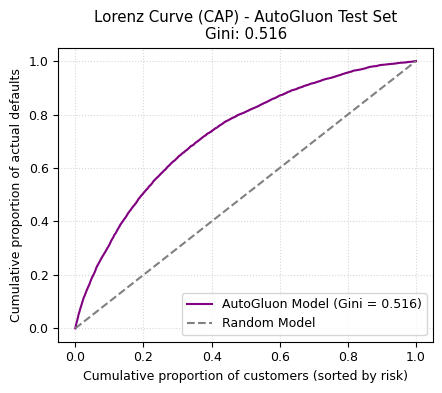

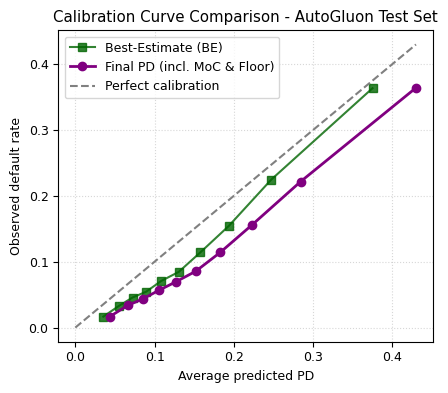

Saved AutoGluon IRBA-compliant plots to: /content/thesis_plots


In [60]:
plt.rcParams.update({
    "font.size": 9
})

# ============================================================
# 1. Lorenz curve (CAP / Cumulative Gains) - AutoGluon
# ============================================================

# Evaluate the discriminatory power of the PD model.
# Customers are sorted from highest predicted risk to lowest.
#
# Interpretation:
# - A curve far above the diagonal indicates strong risk separation.
# - The diagonal represents a random model.
# - The Gini coefficient summarizes discrimination:
#
#   Gini < 0.20  -> weak
#   0.20 - 0.40  -> acceptable
#   0.40 - 0.50  -> good
#   > 0.50       -> strong
#
# In banking practice, Gini is one of the standard measures
# for validating rating systems and PD models.

# Create DataFrame and sort observations by predicted PD
df_lorenz = pd.DataFrame({"y_true": y_test_true, "y_proba": y_test_proba})
df_lorenz = df_lorenz.sort_values(by="y_proba", ascending=False).reset_index(drop=True)

# Cumulative percentage of customers
cum_population = np.arange(1, len(df_lorenz) + 1) / len(df_lorenz)
# Cumulative percentage of observed defaults
cum_defaults = df_lorenz["y_true"].cumsum() / df_lorenz["y_true"].sum()

# Convert ROC-AUC into Gini coefficient
roc_auc = roc_auc_score(y_test_true, y_test_proba)
gini_score = 2 * roc_auc - 1

plt.figure(figsize=(4.5, 4))
plt.plot(cum_population, cum_defaults, color="purple", label=f"AutoGluon Model (Gini = {gini_score:.3f})")
# Random model benchmark
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Model")

plt.xlabel("Cumulative proportion of customers (sorted by risk)")
plt.ylabel("Cumulative proportion of actual defaults")
plt.title(f"Lorenz Curve (CAP) - AutoGluon Test Set\nGini: {gini_score:.3f}")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
lorenz_path = os.path.join(PLOT_DIR, "lorenz_curve_ag_test.png")
plt.savefig(lorenz_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ============================================================
# 2. Combined Calibration Curve (Reliability Diagram) - AutoGluon
# ============================================================
# Purpose:
# Evaluate whether predicted PD values correspond to observed default frequencies.
#
# This plot compares two distinct stages of the IRBA model pipeline:
#
# 1) Best-Estimate (BE) PD:
#    Represents the unbiased estimate of the expected default probability after the
#    alpha-shift calibration step. It is evaluated before applying conservatism adjustments
#    such as MoC_A, MoC_C, or the regulatory PD floor. A well-calibrated BE model should
#    closely follow the diagonal reference line across all risk segments.
#
# 2) Final PD:
#    Evaluated after conservatism adjustments (MoC and the PD floor). Therefore, the final
#    PD is expected to be conservative. For final PDs, points slightly below the diagonal
#    are not necessarily problematic, because MoC intentionally increases the PD estimate.
#    This line indicates the built-in level of regulatory conservatism.
#
# Interpretation:
# - Points on the diagonal indicate perfect calibration.
#
# - Points above the diagonal:
#     Observed default rate > predicted PD -> the model underestimates risk.
#
# - Points below the diagonal:
#     Observed default rate < predicted PD -> the model overestimates risk / applies conservatism.

# 1. Split observations into 10 equally populated risk buckets for Best-Estimate
prob_true_be, prob_pred_be = calibration_curve(
    y_test_final,
    pd_test_be,       # BE-probability after Alpha-shift
    n_bins=10,
    strategy="quantile"
)

# 2. Split observations into 10 equally populated risk buckets for Final PD
prob_true_final, prob_pred_final = calibration_curve(
    y_test_true,
    pd_test_final,     # Final AutoGluon PD (incl. MoC & Floor)
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(4.5, 4))

# Plot Best-Estimate Line (Green)
plt.plot(prob_pred_be, prob_true_be, "s-", color="darkgreen", alpha=0.8, label="Best-Estimate (BE)")

# Plot Final PD Line (Purple für AutoGluon)
plt.plot(prob_pred_final, prob_true_final, "o-", color="purple", lw=2, label="Final PD (incl. MoC & Floor)")

# Perfect calibration benchmark reference line (up to the maximum predicted value)
max_val = max(max(prob_pred_be), max(prob_pred_final)) if len(prob_pred_final) > 0 else 1.0
plt.plot([0, max_val], [0, max_val], linestyle="--", color="gray", label="Perfect calibration")

plt.xlabel("Average predicted PD")
plt.ylabel("Observed default rate")
plt.title("Calibration Curve Comparison - AutoGluon Test Set")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
calib_path = os.path.join(PLOT_DIR, "calibration_curve_comparison_ag_test.png")
plt.savefig(calib_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved AutoGluon IRBA-compliant plots to:", PLOT_DIR)


## 15.1) Save Output

In [61]:
# calculate Gini-coefficient
auc_be = roc_auc_score(y_test_final, pd_test_be)
gini_be = 2 * auc_be - 1

auc_final = roc_auc_score(y_test_final, pd_test_final)
gini_final = 2 * auc_final - 1

# Calculate calibration quality using the Brier Score
# Lower values indicate better calibration and probability accuracy.
brier_be = brier_score_loss(y_test_final, pd_test_be)
brier_final = brier_score_loss(y_test_final, pd_test_final)

# Store all evaluation metrics in a DataFrame
irba_metrics_summary = pd.DataFrame({
    "Model_Stage": ["Best-Estimate (BE)", "Final (incl. MoC & Floor)"],
    "Gini_Coefficient": [gini_be, gini_final],
    "Brier_Score_Calibration": [brier_be, brier_final]
})

# save as csv
irba_metrics_summary.to_csv(os.path.join(OUT_DIR, "irba_performance_metrics.csv"), index=False)


print("H2O CORE IRBA PERFORMANCE METRICS (TEST SET)")
print(irba_metrics_summary.to_string(index=False))


H2O CORE IRBA PERFORMANCE METRICS (TEST SET)
              Model_Stage  Gini_Coefficient  Brier_Score_Calibration
       Best-Estimate (BE)          0.516417                 0.092142
Final (incl. MoC & Floor)          0.515136                 0.094243
